# Detección de vehículos mediante clustering de datos LIDAR

**Objetivo:** a partir de una nube de puntos capturada por un LIDAR de infraestructura,
detectar cuántos vehículos hay presentes, aplicando:
1. Preprocesado (limpieza de puntos y eliminación del suelo)
2. Clustering con DBSCAN
3. Clustering con K-Means (configurado según el resultado de DBSCAN)

## 1. Librerías utilizadas

- **pandas**: para cargar el CSV como una tabla (`DataFrame`) y poder filtrar,
  seleccionar columnas y hacer estadísticas descriptivas fácilmente.
- **numpy**: la base numérica de Python científico. La usamos para trabajar con
  los puntos como arrays de números (vectores y matrices), mucho más rápido que
  usar listas de Python normales.
- **matplotlib**: para dibujar gráficas (dispersión de puntos, histogramas) y
  poder inspeccionar visualmente la nube de puntos y los resultados.
- **open3d**: librería especializada en nubes de puntos 3D. La usamos para
  detectar automáticamente el plano del suelo (algoritmo RANSAC), algo tedioso
  de programar a mano desde cero.
- **scikit-learn**: aquí están implementados los algoritmos de clustering que
  pide la práctica, `DBSCAN` y `KMeans`, ya optimizados y listos para usar.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from sklearn.cluster import DBSCAN, KMeans

## 2. Carga y exploración de los datos

Antes de aplicar cualquier algoritmo, es importante entender qué contienen los datos:
cuántos puntos hay, qué rango de valores tienen, y si hay puntos "vacíos" o inválidos
que haya que descartar.

In [30]:
df = pd.read_csv('data/1_coche.csv')
df.head()

,x,y,z,intensity,t,reflectivity,ring,ambient,range
0,-0.000000,0.000000,0.000000,0.0,1181241184,0,0,0,0
1,-0.000000,0.000000,0.000000,16.0,0,0,0,1470,0
2,-0.000000,0.000000,0.000000,13.0,49720,0,0,1025,0
3,-13.000649,2.733196,13.144561,14.0,99080,3,0,649,18670
4,-12.894675,2.793606,13.054574,12.0,150920,2,0,702,18542


In [31]:
print("Número de puntos:", len(df))
print("Columnas:", list(df.columns))
df.info()

Número de puntos: 131072
Columnas: ['x', 'y', 'z', 'intensity', 't', 'reflectivity', 'ring', 'ambient', 'range']
<class 'pandas.DataFrame'>
RangeIndex: 131072 entries, 0 to 131071
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   x             131072 non-null  float64
 1   y             131072 non-null  float64
 2   z             131072 non-null  float64
 3   intensity     131072 non-null  float64
 4   t             131072 non-null  int64  
 5   reflectivity  131072 non-null  int64  
 6   ring          131072 non-null  int64  
 7   ambient       131072 non-null  int64  
 8   range         131072 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 9.0 MB


### 2.1 Detección de puntos inválidos

El sensor genera una fila por cada disparo láser, incluso cuando no recibe ningún
retorno (por ejemplo, si el láser apunta al cielo o muy lejos). Estos "disparos vacíos"
se identifican porque su columna `range` (distancia al punto) vale 0.

Antes de limpiar, comprobamos cuántos puntos son inválidos.

In [32]:
puntos_invalidos = (df['range'] == 0).sum()
puntos_validos = (df['range'] > 0).sum()

print(f"Puntos inválidos (range=0): {puntos_invalidos} ({puntos_invalidos/len(df)*100:.1f}%)")
print(f"Puntos válidos (range>0): {puntos_validos} ({puntos_validos/len(df)*100:.1f}%)")

Puntos inválidos (range=0): 74025 (56.5%)
Puntos válidos (range>0): 57047 (43.5%)


### 2.2 Limpieza: nos quedamos solo con los puntos válidos

Filtramos el DataFrame para descartar los disparos sin retorno (`range == 0`).
También descartamos, por precaución, puntos con un `range` absurdamente grande,
que podrían ser reflejos erróneos o ruido del sensor.

In [33]:
df_limpio = df[(df['range'] > 0) & (df['range'] < 30000)].copy()
print(f"Puntos antes de limpiar: {len(df)}")
print(f"Puntos después de limpiar: {len(df_limpio)}")

Puntos antes de limpiar: 131072
Puntos después de limpiar: 56568


## 3. Primera visualización de la nube de puntos

Antes de aplicar ningún algoritmo, visualizamos los puntos para entender la escena:
¿cómo está orientado el sensor? ¿dónde está el suelo? ¿se distingue algo a simple vista?

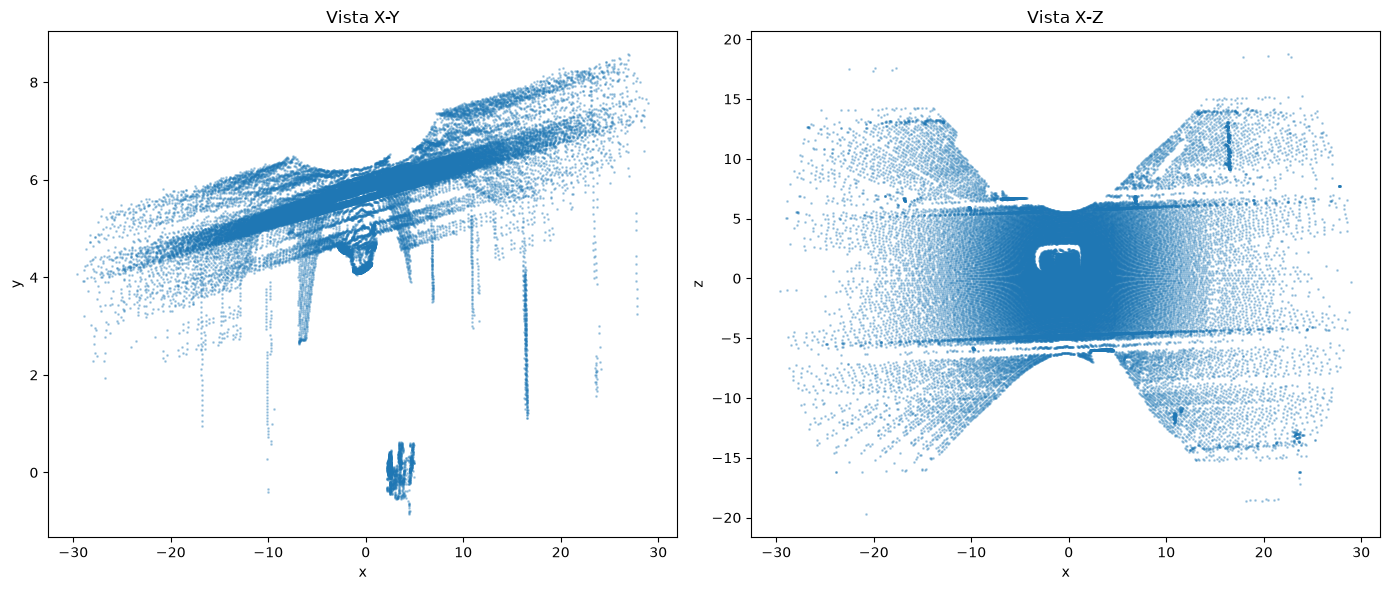

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df_limpio['x'], df_limpio['y'], s=1, alpha=0.3)
axes[0].set_title('Vista X-Y')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

axes[1].scatter(df_limpio['x'], df_limpio['z'], s=1, alpha=0.3)
axes[1].set_title('Vista X-Z')
axes[1].set_xlabel('x')
axes[1].set_ylabel('z')

plt.tight_layout()
plt.show()

## 4. Eliminación del suelo

El suelo (carretera) es un plano, pero no está perfectamente horizontal respecto a los
ejes del sensor — está inclinado. Para encontrarlo automáticamente, sea cual sea su
orientación, usamos el algoritmo **RANSAC** (Random Sample Consensus):

1. Elige 3 puntos al azar de la nube.
2. Calcula el plano que pasa exactamente por esos 3 puntos.
3. Cuenta cuántos puntos del resto de la nube están "cerca" de ese plano (dentro de
   un margen de tolerancia).
4. Repite esto muchas veces con distintos tríos de puntos al azar.
5. Se queda con el plano que consiguió más puntos cerca de él.

La idea es que, como el suelo es la superficie con más puntos en la escena, el plano
que mejor "explica" a la mayoría de puntos va a ser, casi con toda seguridad, el suelo.

### 4.1 Aplicar RANSAC para encontrar y quitar el suelo

Usamos la función `segment_plane` de Open3D, que implementa el algoritmo RANSAC
explicado anteriormente. Le pasamos tres parámetros: cuántos puntos definen cada
plano candidato, cuánto margen de tolerancia usamos para considerar un punto
"cerca" del plano, y cuántas veces repetimos el proceso.

In [35]:
# Convertimos nuestros puntos (x,y,z) al formato que espera Open3D
puntos_xyz = df_limpio[['x', 'y', 'z']].to_numpy()

nube = o3d.geometry.PointCloud()
nube.points = o3d.utility.Vector3dVector(puntos_xyz)

# RANSAC: busca el plano que mejor explica la mayoría de los puntos
plane_model, inliers = nube.segment_plane(
    distance_threshold=0.15,   # margen de tolerancia: 15 cm
    ransac_n=3,                # puntos usados para definir cada plano candidato
    num_iterations=1000        # número de intentos aleatorios
)

a, b, c, d = plane_model
print(f"Plano encontrado: {a:.4f}x + {b:.4f}y + {c:.4f}z + {d:.4f} = 0")
print(f"Puntos de suelo (inliers): {len(inliers)}")
print(f"Puntos que NO son suelo: {len(puntos_xyz) - len(inliers)}")

Plano encontrado: -0.0623x + 0.9970y + 0.0457z + -5.7984 = 0
Puntos de suelo (inliers): 40872
Puntos que NO son suelo: 15696


### 4.2 Función reutilizable de visualización 3D

Para no repetir el mismo bloque de código de plotly cada vez que queramos visualizar
algo, definimos una función una única vez.

In [36]:
def plot_3d(grupos, titulo=""):
    """
    grupos: diccionario {nombre: (array_de_puntos, color)}
    """
    fig = go.Figure()
    for nombre, (puntos, color) in grupos.items():
        fig.add_trace(go.Scatter3d(
            x=puntos[:, 0], y=puntos[:, 1], z=puntos[:, 2],
            mode='markers',
            marker=dict(size=2, color=color, opacity=0.6),
            name=nombre
        ))
    fig.update_layout(
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                    aspectmode='data'),
        title=titulo,
        width=900, height=700,
        margin=dict(l=0, r=0, b=0, t=30)
    )
    fig.show()

# La usamos para ver suelo vs. no-suelo
plot_3d({'Suelo': (suelo, 'tan'), 'No suelo': (no_suelo, 'red')}, "Suelo vs. resto")

## 5. Clustering con DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) agrupa puntos
según su densidad: si un punto tiene suficientes vecinos cerca, forma parte de un
cluster; si está aislado, se marca como ruido. A diferencia de K-Means, no necesita
que le digamos de antemano cuántos clusters buscar.

Parámetros clave:
- `eps`: distancia máxima entre dos puntos para considerarlos "vecinos"
- `min_samples`: número mínimo de vecinos que necesita un punto para no ser ruido

### 5.1 Aplicar DBSCAN sobre los puntos "no suelo"

In [37]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1, min_samples=15)
labels = db.fit_predict(no_suelo)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_ruido = list(labels).count(-1)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos marcados como ruido: {n_ruido} de {len(labels)}")

Clusters encontrados: 17
Puntos marcados como ruido: 495 de 15707


In [42]:
# Un color distinto por cada cluster (el ruido, -1, en gris)
etiquetas_unicas = sorted(set(labels))
colores_paleta = ['red', 'blue', 'green', 'orange', 'purple', 'brown',
                   'pink', 'olive', 'cyan', 'magenta']

grupos = {}
for etiqueta in etiquetas_unicas:
    puntos_cluster = no_suelo[labels == etiqueta]
    if etiqueta == -1:
        nombre = "Ruido"
        color = "lightgray"
    else:
        nombre = f"Cluster {etiqueta}"
        color = colores_paleta[etiqueta % len(colores_paleta)]
    grupos[nombre] = (puntos_cluster, color)

plot_3d(grupos, "Clusters encontrados por DBSCAN")

In [39]:
def altura_sobre_suelo(puntos, plane_model):
    a, b, c, d = plane_model
    normal = np.array([a, b, c])
    distancias = (puntos @ normal + d) / np.linalg.norm(normal)
    return distancias

# Prueba con un cluster concreto, por ejemplo el 0
puntos_cluster_0 = no_suelo[labels == 0]
alturas = altura_sobre_suelo(puntos_cluster_0, plane_model)
print(f"Altura mínima: {alturas.min():.2f} m")
print(f"Altura máxima: {alturas.max():.2f} m")
print(f"Rango de altura (alto del objeto): {alturas.max() - alturas.min():.2f} m")

Altura mínima: -1.66 m
Altura máxima: -0.34 m
Rango de altura (alto del objeto): 1.32 m


### 5.3 Calcular las dimensiones de TODOS los clusters

Repetimos el cálculo anterior para cada cluster encontrado por DBSCAN, y guardamos
los resultados en una tabla para poder compararlos y aplicar el filtro de vehículo.

In [ ]:
def calcular_dimensiones(puntos, plane_model):
    a, b, c, d = plane_model
    normal = np.array([a, b, c])
    normal = normal / np.linalg.norm(normal)  # normal "de longitud 1", para simplificar

    # Altura de cada punto (igual que ya sabes hacer)
    alturas = (puntos @ np.array([a, b, c]) + d) / np.linalg.norm([a, b, c])
    alto = alturas.max() - alturas.min()

    # "Aplanamos": a cada punto le restamos su altura en la dirección de la normal
    puntos_planos = puntos - alturas.reshape(-1, 1) * normal

    # Elegimos dos direcciones perpendiculares a la normal, dentro del plano
    ayuda = np.array([1.0, 0.0, 0.0]) if abs(normal[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    e1 = np.cross(normal, ayuda)
    e1 = e1 / np.linalg.norm(e1)
    e2 = np.cross(normal, e1)

    # Coordenadas de cada punto dentro del plano, en esas dos direcciones
    coord1 = puntos_planos @ e1
    coord2 = puntos_planos @ e2

    dim1 = coord1.max() - coord1.min()
    dim2 = coord2.max() - coord2.min()
    largo, ancho = max(dim1, dim2), min(dim1, dim2)

    return largo, ancho, alto

In [46]:
resultados = []

for etiqueta in sorted(set(labels)):
    if etiqueta == -1:
        continue  # el ruido no es un cluster, lo saltamos

    puntos_cluster = no_suelo[labels == etiqueta]
    largo, ancho, alto = calcular_dimensiones(puntos_cluster, plane_model)

    resultados.append({
        'cluster': etiqueta,
        'n_puntos': len(puntos_cluster),
        'largo': largo,
        'ancho': ancho,
        'alto': alto
    })

tabla_clusters = pd.DataFrame(resultados)
tabla_clusters

,cluster,n_puntos,largo,ancho,alto
0,0,222,8.695815,2.004464,1.324362
1,1,2537,23.459551,8.440381,5.941485
2,2,1891,23.489369,7.417963,5.750496
3,3,219,10.049169,2.487425,1.362873
4,4,1612,8.701426,2.783621,1.223266
5,5,3112,4.080091,1.895139,1.439955
6,6,10,1.360433,0.925250,0.307203
7,7,14,0.934879,0.290881,0.977371
8,8,2646,36.803022,2.686962,3.281304
9,9,1743,22.152644,7.491341,0.489644
